# Julia Sets for $f_c(z) = z^d + c$

This notebook is a library for generating images of **Julia sets** for the polynomial family $f_c(z) = z^d + c$.

**Primary use case:** Generate a labelled dataset — images paired with their parameter $c$ — for training a neural network to recover $c$ from a Julia set image.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os

## Mathematical background

Fix a complex parameter $c$ and a degree $d \geq 2$.  The map $f_c(z) = z^d + c$ acts on $\mathbb{C}$.  For a starting point $z_0$, write $z_n = f_c^{\circ n}(z_0)$ for the $n$-th iterate.

**Filled Julia set:** $K_c = \{z_0 \in \mathbb{C} : |z_n| \not\to \infty\}$ — the set of non-escaping initial conditions.

**Julia set:** $J_c = \partial K_c$ — the boundary of the filled Julia set.  This is where the interesting fractal structure lives.

**Escape radius.** Let $\delta(r) = r^d - r - |c|$ for $r \geq 0$.  Its derivative $\delta'(r) = dr^{d-1} - 1$ is $0$ at $r_* = (1/d)^{1/(d-1)}$, so $\delta$ has a unique minimum there and is strictly increasing on $[r_*, \infty)$.  Since $\delta(r) \to +\infty$, there is a unique root $R = R(d,|c|) > r_*$, i.e. the unique positive solution to
$$r^d - r - |c| = 0.$$

**Escape theorem.** *If $|z_0| > R$ then $|z_n| \to \infty$.*

*Proof.* Let $\delta_0 = \delta(|z_0|) > 0$.  By the triangle inequality,
$$|z_1| \geq |z_0|^d - |c| = |z_0| + \delta(|z_0|) = |z_0| + \delta_0.$$
So $|z_1| > |z_0| > R$.  Inductively, $|z_n| > R$ for all $n$, so the same bound applies at each step.  Since $\delta$ is increasing on $[R, \infty)$ and $|z_n| \geq |z_0|$ for all $n$:
$$|z_{n+1}| \geq |z_n| + \delta(|z_n|) \geq |z_n| + \delta(|z_0|) = |z_n| + \delta_0.$$
Thus $|z_n| \geq |z_0| + n\,\delta_0 \to_{n\to\infty} \infty$. $\square$

For $d = 2$ there is a closed form: $R = \tfrac{1}{2}(1 + \sqrt{1 + 4|c|})$.  Note $R = 2$ when $|c| = 2$, and $R < 2$ for all $|c| < 2$, so using the exact $R$ is always at least as tight as the traditional bound of 2.

**Escape time algorithm:** Iterate until $|z_n| > R$ or $n = N_{\max}$.  The iteration count $n$ encodes proximity to $J_c$: slow-escaping points are close to the boundary.

**Smooth coloring:** The raw integer escape time produces visible banding.  The correction
$$\mu = n - \frac{\log\!\bigl(\log|z_n|\,/\,\log R\bigr)}{\log d}$$
is continuous as a function of the initial point, giving smooth gradients.  For $d = 2$ this reduces to $\mu = n - \log_2(\log_2|z_n| - \log_2 R)$.

In [ ]:
def _escape_radius(d, abs_c):
    """
    Tight escape radius for z**d + c: the unique positive root of r**d - r - |c| = 0.

    For any |z| > R the orbit of z is guaranteed to diverge, since
    |z|**d - |z| - |c| > 0  ⟺  |z| > R(d, |c|).

    This is strictly smaller than 2 whenever |c| < 2 (equal at |c|=2), so it
    shrinks the escape ball and speeds up the algorithm.

    For d=2 there is a closed form.  Otherwise Newton's method converges in a
    handful of steps because f(r) = r**d - r - |c| is convex for r > r*.
    """
    k = abs_c
    if d == 2:
        return 0.5 * (1.0 + np.sqrt(1.0 + 4.0 * k))
    # Start Newton at the known upper bound (1 + k)**(1/(d-1)).
    r = max((1.0 + k) ** (1.0 / (d - 1)), 1.0 + 1e-6)
    for _ in range(50):
        fr = r ** d - r - k
        dfr = d * r ** (d - 1) - 1.0
        step = fr / dfr
        r -= step
        if abs(step) < 1e-12 * r:
            break
    return r


class JuliaSet:
    """
    Julia set for f(z) = z**d + c.

    Parameters
    ----------
    c : complex
        The parameter c.  Interesting dynamics occur for |c| <= 2.
    d : int
        Polynomial degree.  d=2 gives the classic quadratic family.
    height : int
        Image height in pixels.
    width : int
        Image width in pixels.
    zoom : float
        The viewing window spans [-1/zoom, 1/zoom] on both axes.
        zoom=0.8 shows the region [-1.25, 1.25] x [-1.25i, 1.25i].
    """

    def __init__(self, c, d=2, height=256, width=256, zoom=0.8):
        self.c = complex(c)
        self.d = int(d)
        self.height = height
        self.width = width
        self.zoom = zoom

        # Pixel grid as complex numbers.
        # Real axis: left to right.  Imaginary axis: bottom to top (y flipped).
        x = np.linspace(-1.0, 1.0, width) / zoom
        y = np.linspace(1.0, -1.0, height) / zoom
        self.coords = x[np.newaxis, :] + 1j * y[:, np.newaxis]

        # Exact escape radius: smallest R such that |z| > R guarantees escape.
        self.escape_radius = _escape_radius(self.d, abs(self.c))

        self.escape_time = None    # float array: iteration when each pixel escaped
        self.smooth_escape = None  # float array: smoothed escape time
        self.in_set = None         # bool array: True = in filled Julia set

    def compute(self, max_iter=256):
        """
        Run the escape time algorithm for every pixel simultaneously.

        Uses vectorised NumPy operations.  At each step only the 'active'
        (not yet escaped) pixels are updated, so computation short-circuits
        as pixels escape.  Avoids computing sqrt by comparing |z|^2 > R^2
        where R is the tight escape radius for (d, c).

        Returns self for method chaining.
        """
        Z = self.coords.copy()
        c, d = self.c, self.d
        R2 = self.escape_radius ** 2

        escape_time = np.full(Z.shape, float(max_iter), dtype=np.float64)
        active = np.ones(Z.shape, dtype=bool)

        for i in range(max_iter):
            Z[active] = Z[active] ** d + c
            # Compare |z|^2 > R^2 instead of |z| > R to avoid sqrt each iteration.
            newly_escaped = active & (Z.real ** 2 + Z.imag ** 2 > R2)
            escape_time[newly_escaped] = float(i + 1)
            active[newly_escaped] = False
            if not active.any():
                break

        self.escape_time = escape_time
        self.in_set = active  # pixels still active never escaped

        # Smooth escape time: mu = n - log(log|z_n| / log(R)) / log(d)
        # abs_Z is the modulus at the first iterate that exceeded R.
        abs_Z = np.sqrt(Z.real ** 2 + Z.imag ** 2)
        # When c=0 the escape radius is exactly 1; clamp to avoid log(0).
        R_log = max(self.escape_radius, 1.0 + 1e-10)
        abs_Z = np.maximum(abs_Z, R_log + 1e-10)

        smooth = escape_time - np.log(np.log(abs_Z) / np.log(R_log)) / np.log(d)
        smooth[self.in_set] = 0.0
        self.smooth_escape = smooth

        return self

    def render(self, max_iter=256):
        """
        Return a float32 grayscale image with values in [0, 1].

        The filled Julia set is black (0).  Exterior pixels are brighter
        for slower-escaping points, i.e. those closest to the Julia set.
        The smooth escape time is normalised linearly across the exterior.
        """
        if self.smooth_escape is None:
            self.compute(max_iter)

        s = self.smooth_escape.copy()
        exterior = ~self.in_set
        if exterior.any():
            lo, hi = s[exterior].min(), s[exterior].max()
            s[exterior] = (s[exterior] - lo) / (hi - lo + 1e-10)
        s[self.in_set] = 0.0

        return s.astype(np.float32)

    def save(self, path, max_iter=256):
        """Save as an 8-bit grayscale PNG (or any format PIL supports)."""
        arr = (self.render(max_iter) * 255).astype(np.uint8)
        Image.fromarray(arr).save(path)

    def show(self, max_iter=256, ax=None):
        """Display the Julia set using matplotlib."""
        img = self.render(max_iter)
        if ax is None:
            _, ax = plt.subplots()
        ax.imshow(img, cmap='gray', vmin=0, vmax=1)
        c = self.c
        sign = '+' if c.imag >= 0 else '-'
        ax.set_title(f'$c = {c.real:.3f} {sign} {abs(c.imag):.3f}i$,  $d={self.d}$')
        ax.axis('off')
        return ax

## Examples

Some representative $c$ values for $d=2$:

| $c$ | Description |
|-----|-------------|
| $0$ | Unit circle |
| $-1$ | Basilica (period-2 Fatou component) |
| $-0.123 + 0.745i$ | Douady's rabbit (period-3) |
| $-2$ | Real segment $[-2, 2]$ (tip of Mandelbrot set) |
| $i$ | Dendrite (no interior Fatou component) |
| $-0.7 + 0.3i$ | Connected but geometrically complex |
| $0.4 + 0.5j$ | Cantor set — $c$ is outside the Mandelbrot set |

In [ ]:
examples = [
    (0+0j,          'd=2, c=0'),
    (-1+0j,         'Basilica'),
    (-0.123+0.745j, "Douady's rabbit"),
    (1j,            'Dendrite'),
    (-0.7+0.3j,     'Connected, complex'),
    (0.4+0.5j,      'Cantor set'),
]

fig, axes = plt.subplots(2, 3, figsize=(10, 7))
for ax, (c, _) in zip(axes.flat, examples):
    JuliaSet(c, d=2, height=300, width=300).show(ax=ax)
plt.tight_layout()
plt.show()

In [ ]:
# d=3 example: each z has 3 preimages, so the Julia set has 3-fold symmetry.
fig, axes = plt.subplots(1, 3, figsize=(11, 4))
for ax, c in zip(axes, [0+0j, -0.2+0.8j, 0.5+0.5j]):
    JuliaSet(c, d=3, height=300, width=300).show(ax=ax)
plt.suptitle('$d = 3$')
plt.tight_layout()
plt.show()

## Dataset generation

To train a neural network to predict $c$ from a Julia set image, we need many $(\text{image}, c)$ pairs covering the parameter space $|c| \leq 2$.

**Sampling uniformly in the disk:** Sampling $r$ uniformly in $[0, 2]$ would oversample the center (area $\propto r^2$, not $r$).  The correct transform is $r = 2\sqrt{U}$ where $U \sim \text{Uniform}[0,1]$, which gives a uniform distribution by area.

**Labels for a regression network:** Since $c = a + bi$ is two real numbers, the natural label is $[\operatorname{Re}(c), \operatorname{Im}(c)]$, a 2-vector.

In [ ]:
def sample_c_in_disk(n, radius=2.0, rng=None, seed=None):
    """
    Sample n complex numbers uniformly from the disk |c| <= radius.

    Uses r = radius * sqrt(U) to achieve uniform area distribution.

    Parameters
    ----------
    rng : np.random.Generator or None
        Pass an existing generator to control the stream (takes precedence over seed).
    seed : int or None
        Convenience shorthand for np.random.default_rng(seed).
    """
    if rng is None:
        rng = np.random.default_rng(seed)
    r = radius * np.sqrt(rng.uniform(0.0, 1.0, n))
    theta = rng.uniform(0.0, 2 * np.pi, n)
    return r * np.exp(1j * theta)


def generate_dataset(
    n_samples,
    height=64,
    width=64,
    d=2,
    max_iter=100,
    zoom=0.8,
    output_dir=None,
    seed=None,
):
    """
    Generate labelled Julia set images for machine learning.

    Samples c uniformly from |c| <= 2 and renders each Julia set.

    Parameters
    ----------
    n_samples : int
        Number of images to generate.
    height, width : int
        Image size in pixels.
    d : int
        Polynomial degree.
    max_iter : int
        Maximum escape-time iterations.
    zoom : float
        Viewing window scale.
    output_dir : str or None
        If provided, saves each image as '{real:.6f}_{imag:.6f}.png' so that
        a fastai label_func can recover c directly from the filename:

            def label_func(fname):
                re, im = fname.stem.split('_')
                return tensor([float(re), float(im)])

    seed : int or None
        Random seed for reproducibility.

    Returns
    -------
    images : np.ndarray, shape (n_samples, height, width), float32
        Grayscale images in [0, 1].  For PyTorch, add a channel dim with
        images[:, np.newaxis, :, :].
    c_values : np.ndarray, shape (n_samples,), complex128
        The parameter c for each image.
    """
    rng = np.random.default_rng(seed)
    c_values = sample_c_in_disk(n_samples, radius=2.0, rng=rng)

    if output_dir is not None:
        os.makedirs(output_dir, exist_ok=True)

    images = np.empty((n_samples, height, width), dtype=np.float32)

    for i, c in enumerate(c_values):
        js = JuliaSet(c, d=d, height=height, width=width, zoom=zoom)
        images[i] = js.compute(max_iter).render()

        if output_dir is not None:
            fname = f'{c.real:.6f}_{c.imag:.6f}.png'
            img_uint8 = (images[i] * 255).astype(np.uint8)
            Image.fromarray(img_uint8).save(os.path.join(output_dir, fname))

        if (i + 1) % max(1, n_samples // 10) == 0:
            print(f'{i + 1}/{n_samples}')

    return images, c_values

### Generating a small dataset

Below: generate 20 images in memory and plot them.  For a real training run, use `output_dir` to write PNGs to disk and load them lazily with a `Dataset` class.

2/20
4/20
6/20
8/20
10/20
12/20
14/20
16/20
18/20
20/20
images: (20, 64, 64) float32
labels: (20, 2) float64


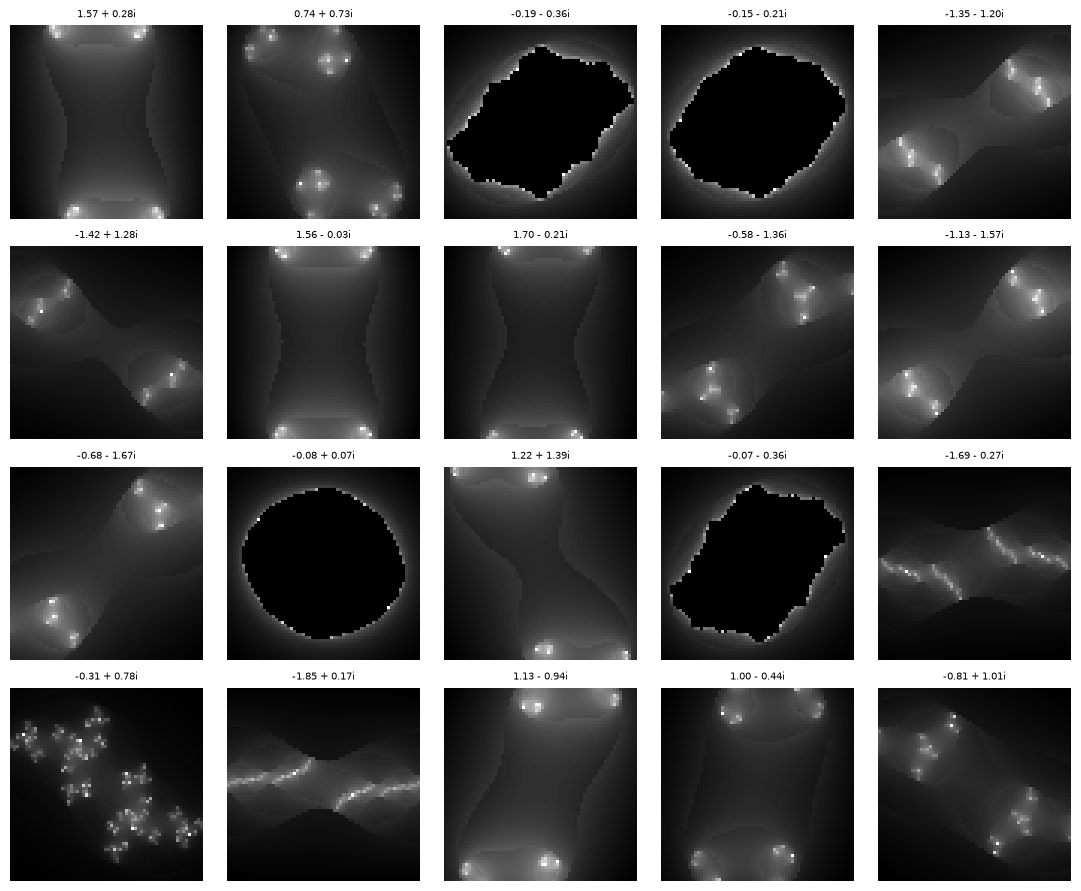

In [9]:
images, c_values = generate_dataset(n_samples=20, height=64, width=64, seed=0)

# Labels as a (N, 2) float array ready for a regression network.
labels = np.stack([c_values.real, c_values.imag], axis=1)
print('images:', images.shape, images.dtype)
print('labels:', labels.shape, labels.dtype)

fig, axes = plt.subplots(4, 5, figsize=(11, 9))
for ax, img, c in zip(axes.flat, images, c_values):
    ax.imshow(img, cmap='gray', vmin=0, vmax=1)
    sign = '+' if c.imag >= 0 else '-'
    ax.set_title(f'{c.real:.2f} {sign} {abs(c.imag):.2f}i', fontsize=7)
    ax.axis('off')
plt.tight_layout()
plt.show()

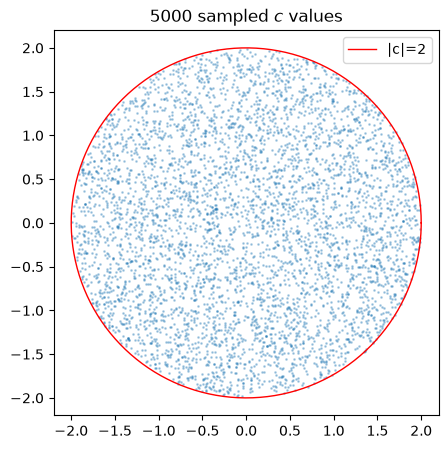

In [10]:
# Verify the sampling covers the disk uniformly.
c_large = sample_c_in_disk(5000, seed=1)
plt.figure(figsize=(5, 5))
plt.scatter(c_large.real, c_large.imag, s=1, alpha=0.3)
theta = np.linspace(0, 2 * np.pi, 300)
plt.plot(2 * np.cos(theta), 2 * np.sin(theta), 'r', lw=1, label='|c|=2')
plt.gca().set_aspect('equal')
plt.legend()
plt.title('5000 sampled $c$ values')
plt.show()